# AG3 - Actividad Guiada 3
---
#### **Nombre**  Carlos Zumba Vásquez
#### **Repositorio Git de la solución:** [https://github.com/czumbav/CZV-Algoritmos-de-Optimizacion/AG3- Actividad Guiada 3/](https://github.com/czumbav/CZV-Algoritmos-de-Optimizacion/tree/main/AG3-%20Actividad%20Guiada%203)

# Carga de librerias

In [1]:
# Google Colab
#!pip install requests    #Hacer llamadas http a paginas de la red
#!pip install tsplib95    #Modulo para las instancias del problema del TSP

# Anaconda
%pip install --user requests
%pip install --user tsplib95

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Carga de los datos del problema

In [2]:
import urllib.request #Hacer llamadas http a paginas de la red
import tsplib95       #Modulo para las instancias del problema del TSP
import math           #Modulo de funciones matematicas. Se usa para exp
import random         #Para generar valores aleatorios


#http://elib.zib.de/pub/mp-testdata/tsp/tsplib/
#Documentacion :
  # http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp95.pdf
  # https://tsplib95.readthedocs.io/en/stable/pages/usage.html
  # https://tsplib95.readthedocs.io/en/v0.6.1/modules.html
  # https://pypi.org/project/tsplib95/

#Descargamos el fichero de datos(Matriz de distancias)
file = "swiss42.tsp" ;
# urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/swiss42.tsp.gz", file + '.gz')
# !gzip -d swiss42.tsp.gz     #Descomprimir el fichero de datos

#URL alternativa
# file = "swiss42.tsp" ;
# urllib.request.urlretrieve("https://raw.githubusercontent.com/mastqe/tsplib/refs/heads/master/swiss42.tsp", file  )

#Coordendas 51-city problem (Christofides/Eilon)
#file = "eil51.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/eil51.tsp.gz", file)

#Coordenadas - 48 capitals of the US (Padberg/Rinaldi)
#file = "att48.tsp" ; urllib.request.urlretrieve("http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/att48.tsp.gz", file)




In [3]:
#Carga de datos y generación de objeto problem
###############################################################################
problem = tsplib95.load(file)

#Nodos
Nodos = list(problem.get_nodes())

#Aristas
Aristas = list(problem.get_edges())



In [4]:
Aristas

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 17),
 (0, 18),
 (0, 19),
 (0, 20),
 (0, 21),
 (0, 22),
 (0, 23),
 (0, 24),
 (0, 25),
 (0, 26),
 (0, 27),
 (0, 28),
 (0, 29),
 (0, 30),
 (0, 31),
 (0, 32),
 (0, 33),
 (0, 34),
 (0, 35),
 (0, 36),
 (0, 37),
 (0, 38),
 (0, 39),
 (0, 40),
 (0, 41),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 17),
 (1, 18),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 22),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 34),
 (1, 35),
 (1, 36),
 (1, 37),
 (1, 38),
 (1, 39),
 (1, 40),
 (1, 41),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 17),
 (2, 18),


In [5]:
#Comprobar el nombre del problema
print(problem.name)

#Comprobar el número de Nodos
print(len(Nodos))

#Comprobar los 10 primeros Nodos
print(Nodos[:10])

#Comprobar las 10 primeras Aristas
print(Aristas[:10])

swiss42
42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]



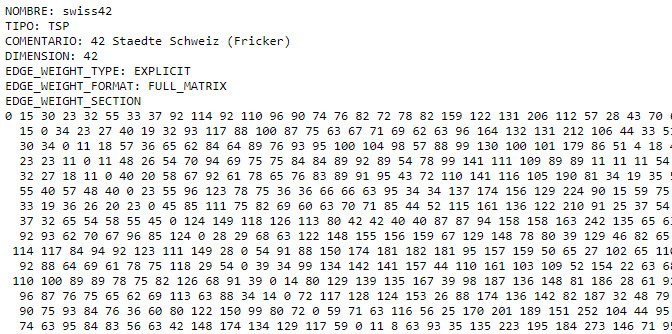

In [6]:
#Probamos algunas funciones del objeto problem

#Distancia entre nodos
problem.get_weight(0, 1)

#Todas las funciones
#Documentación: https://tsplib95.readthedocs.io/en/v0.6.1/modules.html

#dir(problem)

15

In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import MDS  # Multidimensional Scaling o Escalado Multidimensional

def plot_tsp_solution(distance_matrix, tsp_solution):
    """
    Dibuja el grafo de un TSP con las posiciones calculadas mediante MDS y muestra
    solo las aristas correspondientes a la solución del TSP.

    :param distance_matrix: np.ndarray, matriz de distancias entre nodos
    :param tsp_solution: list, lista de nodos en el orden de la solución del TSP
    """
    # Crear el grafo completo
    G = nx.Graph()
    num_nodes = len(distance_matrix)
    for i in range(num_nodes):
        for j in range(i + 1, num_nodes):
            G.add_edge(i, j, weight=distance_matrix[i][j])

    # Usar MDS para calcular posiciones de los nodos
    mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
    positions = mds.fit_transform(distance_matrix)

    # Convertir las posiciones en un diccionario para networkx
    pos = {i: positions[i] for i in range(num_nodes)}

    # Crear un subgrafo con las aristas del camino TSP
    TSP_G = nx.Graph()
    for i in range(len(tsp_solution) - 1):
        u = tsp_solution[i]
        v = tsp_solution[i + 1]
        TSP_G.add_edge(u, v, weight=distance_matrix[u][v])

    # Dibujar el grafo
    plt.figure(figsize=(8, 6))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    # Dibujar las aristas del camino TSP
    nx.draw_networkx_edges(TSP_G, pos, edge_color='red', width=2)

    # Añadir etiquetas a los nodos y pesos de las aristas
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    edge_labels = nx.get_edge_attributes(TSP_G, 'weight')
    nx.draw_networkx_edge_labels(TSP_G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Grafo solucion TSP")
    plt.show()

# Funcionas basicas


In [8]:

#Funcionas basicas
###############################################################################

#Se genera una solucion aleatoria con comienzo en en el nodo 0
def crear_solucion(Nodos):
  solucion = [Nodos[0]]
  for n in Nodos[1:]:
    solucion = solucion + [random.choice(list(set(Nodos) - set({Nodos[0]}) - set(solucion)))]
  return solucion

#Devuelve la distancia entre dos nodos
def distancia(a,b, problem):
  return problem.get_weight(a,b)

#Devuelve la distancia total de una trayectoria/solucion
def distancia_total(solucion, problem):
  distancia_total = 0
  for i in range(len(solucion)-1):
    distancia_total += distancia(solucion[i] ,solucion[i+1] ,  problem)
  return distancia_total + distancia(solucion[len(solucion)-1] ,solucion[0], problem)

sol_temporal = crear_solucion(Nodos)

distancia_total(sol_temporal, problem), sol_temporal

(4807,
 [0,
  5,
  18,
  3,
  39,
  26,
  25,
  12,
  6,
  35,
  41,
  37,
  2,
  15,
  20,
  13,
  19,
  23,
  7,
  4,
  32,
  10,
  24,
  33,
  30,
  11,
  34,
  38,
  8,
  27,
  36,
  17,
  29,
  40,
  22,
  14,
  28,
  1,
  31,
  21,
  9,
  16])

# BUSQUEDA ALEATORIA

Mejor solución: [0, 27, 37, 3, 8, 21, 40, 22, 39, 19, 7, 18, 10, 34, 35, 36, 17, 41, 25, 24, 9, 16, 2, 4, 28, 29, 5, 15, 6, 14, 20, 30, 12, 11, 23, 1, 13, 32, 26, 31, 33, 38]
Distancia     : 3695


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


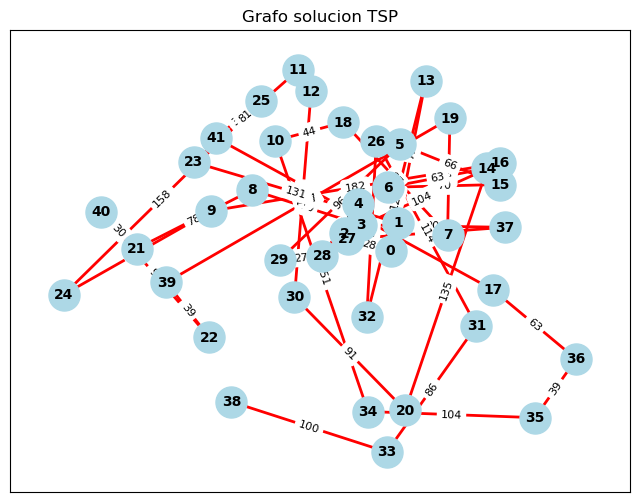

In [9]:
###############################################################################
# BUSQUEDA ALEATORIA
###############################################################################
def busqueda_aleatoria(problem, N):
  #N es el numero de iteraciones
  Nodos = list(problem.get_nodes())

  mejor_solucion = []
  #mejor_distancia = 10e100                         #Inicializamos con un valor alto
  mejor_distancia = float('inf')                    #Inicializamos con un valor alto

  for i in range(N):                                #Criterio de parada: repetir N veces pero podemos incluir otros
    solucion = crear_solucion(Nodos)                #Genera una solucion aleatoria
    distancia = distancia_total(solucion, problem)  #Calcula el valor objetivo(distancia total)

    if distancia < mejor_distancia:                 #Compara con la mejor obtenida hasta ahora
      mejor_solucion = solucion
      mejor_distancia = distancia

  print("Mejor solución:" , mejor_solucion)
  print("Distancia     :" , mejor_distancia)
  return mejor_solucion

#Busqueda aleatoria con 10000 iteraciones
solucion = busqueda_aleatoria(problem, 10000)

plot_tsp_solution(problem.edge_weights, solucion)

# BUSQUEDA LOCAL

In [10]:
###############################################################################
# BUSQUEDA LOCAL
###############################################################################
def genera_vecina(solucion):
  #Generador de soluciones vecinas: 2-opt (intercambiar 2 nodos) Si hay N nodos se generan (N-1)x(N-2)/2 soluciones
  #Se puede modificar para aplicar otros generadores distintos que 2-opt
  #print(solucion)
  mejor_solucion = []
  mejor_distancia = 10e100
  for i in range(1,len(solucion)-1):          #Recorremos todos los nodos en bucle doble para evaluar todos los intercambios 2-opt
    for j in range(i+1, len(solucion)):

      #Se genera una nueva solución intercambiando los dos nodos i,j:
      #  (usamos el operador + que para listas en python las concatena) : ej.: [1,2] + [3] = [1,2,3]
      vecina = solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

      #Se evalua la nueva solución ...
      distancia_vecina = distancia_total(vecina, problem)

      #... para guardarla si mejora las anteriores
      if distancia_vecina <= mejor_distancia:
        mejor_distancia = distancia_vecina
        mejor_solucion = vecina
  return mejor_solucion

#solucion = [1, 47, 13, 41, 40, 19, 42, 44, 37, 5, 22, 28, 3, 2, 29, 21, 50, 34, 30, 9, 16, 11, 38, 49, 10, 39, 33, 45, 15, 24, 43, 26, 31, 36, 35, 20, 8, 7, 23, 48, 27, 12, 17, 4, 18, 25, 14, 6, 51, 46, 32]
print("Distancia Solucion Incial:" , distancia_total(solucion, problem))

nueva_solucion = genera_vecina(solucion)
print("Distancia Mejor Solucion Local:", distancia_total(nueva_solucion, problem))


Distancia Solucion Incial: 3695
Distancia Mejor Solucion Local: 3442


En la iteracion  31 , la mejor solución encontrada es: [0, 1, 30, 38, 22, 24, 40, 21, 39, 9, 23, 8, 29, 28, 3, 4, 6, 7, 14, 16, 15, 37, 36, 35, 31, 17, 19, 13, 5, 26, 12, 11, 25, 41, 10, 18, 2, 27, 32, 34, 33, 20]
Distancia     : 1615


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


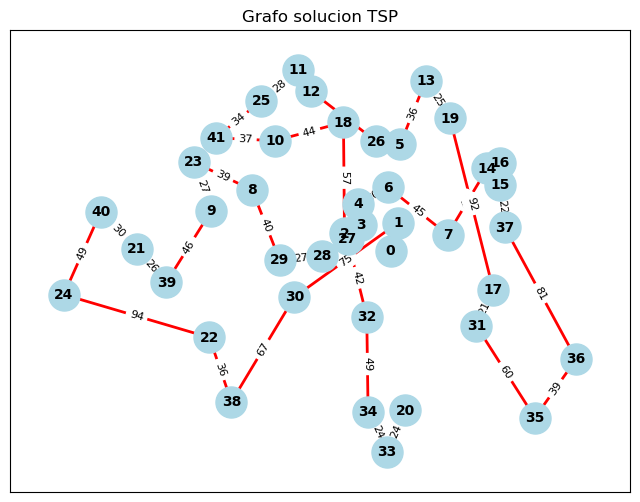

In [11]:
#Busqueda Local:
#  - Sobre el operador de vecindad 2-opt(funcion genera_vecina)
#  - Sin criterio de parada, se para cuando no es posible mejorar.
def busqueda_local(problem):
  mejor_solucion = []

  #Generar una solucion inicial de referencia(aleatoria)
  solucion_referencia = crear_solucion(Nodos)
  mejor_distancia = distancia_total(solucion_referencia, problem)

  iteracion=0             #Un contador para saber las iteraciones que hacemos
  while(1):
    iteracion +=1         #Incrementamos el contador
    #print('#',iteracion)

    #Obtenemos la mejor vecina ...
    vecina = genera_vecina(solucion_referencia)

    #... y la evaluamos para ver si mejoramos respecto a lo encontrado hasta el momento
    distancia_vecina = distancia_total(vecina, problem)

    #Si no mejoramos hay que terminar. Hemos llegado a un minimo local(según nuestro operador de vencindad 2-opt)
    if distancia_vecina < mejor_distancia:
      #mejor_solucion = copy.deepcopy(vecina)   #Con copia profunda. Las copias en python son por referencia
      mejor_solucion = vecina                   #Guarda la mejor solución encontrada
      mejor_distancia = distancia_vecina

    else:
      print("En la iteracion ", iteracion, ", la mejor solución encontrada es:" , mejor_solucion)
      print("Distancia     :" , mejor_distancia)
      return mejor_solucion

    solucion_referencia = vecina

sol = busqueda_local(problem)

plot_tsp_solution(problem.edge_weights, sol)

# SIMULATED ANNEALING


In [12]:
###############################################################################
# SIMULATED ANNEALING
###############################################################################
#Generador de 1 solucion vecina 2-opt 100% aleatoria (intercambiar 2 nodos)
#Mejorable eligiendo otra forma de elegir una vecina.
def genera_vecina_aleatorio(solucion):

  #Se eligen dos nodos aleatoriamente
  i,j = sorted(random.sample( range(1,len(solucion)) , 2))

  #Devuelve una nueva solución pero intercambiando los dos nodos elegidos al azar
  return solucion[:i] + [solucion[j]] + solucion[i+1:j] + [solucion[i]] + solucion[j+1:]

#Funcion de probabilidad para aceptar peores soluciones
def probabilidad(T,d):
  if random.random() <  math.exp( -1*d / T)  :
    return True
  else:
    return False

#Funcion de descenso de temperatura
def bajar_temperatura(T):
  return T*0.99

La mejor solución encontrada es [0, 1, 6, 28, 29, 30, 22, 38, 33, 20, 31, 2, 39, 21, 40, 24, 9, 3, 8, 23, 41, 25, 11, 5, 13, 19, 14, 16, 37, 15, 36, 35, 17, 7, 26, 18, 12, 10, 4, 27, 32, 34]
con una distancia total de 2004


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


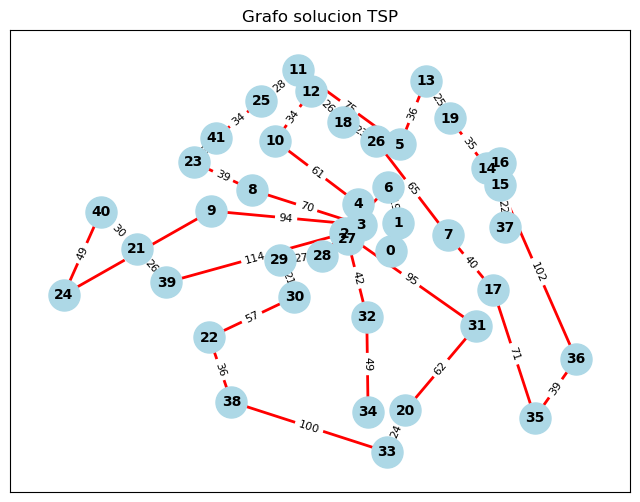

In [13]:
def recocido_simulado(problem, TEMPERATURA ):
  #problem = datos del problema
  #T = Temperatura

  solucion_referencia = crear_solucion(Nodos)
  distancia_referencia = distancia_total(solucion_referencia, problem)

  mejor_solucion = []             #x* del seudocodigo
  mejor_distancia = 10e100        #F* del seudocodigo

  N=0
  while TEMPERATURA > .0001:
    N+=1
    #Genera una solución vecina
    vecina =genera_vecina_aleatorio(solucion_referencia)

    #Calcula su valor(distancia)
    distancia_vecina = distancia_total(vecina, problem)

    #Si es la mejor solución de todas se guarda(siempre!!!)
    if distancia_vecina < mejor_distancia:
        mejor_solucion = vecina
        mejor_distancia = distancia_vecina

    #Si la nueva vecina es mejor se cambia
    #Si es peor se cambia según una probabilidad que depende de T y delta(distancia_referencia - distancia_vecina)
    if distancia_vecina < distancia_referencia or probabilidad(TEMPERATURA, abs(distancia_referencia - distancia_vecina) ) :
      #solucion_referencia = copy.deepcopy(vecina)
      solucion_referencia = vecina
      distancia_referencia = distancia_vecina

    #Bajamos la temperatura
    TEMPERATURA = bajar_temperatura(TEMPERATURA)

  print("La mejor solución encontrada es " , end="")
  print(mejor_solucion)
  print("con una distancia total de " , end="")
  print(mejor_distancia)
  return mejor_solucion

sol  = recocido_simulado(problem, 10000000)

plot_tsp_solution(problem.edge_weights, sol)

---
# Actividades Extra

**Mejora de algoritmo de búsqueda local**

*   Multiarranque
*   Busqueda en entornos variables

**Recocido simulado**

*   Mejora en la selección de vecinos



## Mejora de algoritmo de búsqueda local en entornos variables

In [14]:
###############################################################################
# BUSQUEDA POR ENTORNOS VARIABLES
# VNS - VARIABLE NEIGHBORHOOD SEARCH
###############################################################################
###############################################################################
# ENTORNO 1: SWAP
###############################################################################
def genera_vecina_swap(solucion):
    """
    Genera la mejor solución vecina usando el operador SWAP.
    SWAP: Intercambia la posición de dos nodos de la ruta.

    Ejemplo:
    [1, 2, 3, 4, 5]
        ↑        ↑
    Resultado posible:
    [1, 5, 3, 4, 2]
    """

    # Creamos una copia de la solución actual.Esta será inicialmente la mejor solución conocida.
    mejor_solucion = solucion[:]

    # Calculamos la distancia de la solución actual. Servirá como referencia para comparar las soluciones vecinas.
    mejor_distancia = distancia_total(solucion, problem)

    # El primer bucle selecciona el primer nodo que se desea intercambiar.
    # Se empieza desde la posición 1 para mantener fijo el primer nodo, que normalmente representa el origen de la ruta.
    for i in range(1, len(solucion) - 1):

        # El segundo bucle selecciona el segundo nodo. Se comienza en i + 1 para evitar: 
        # comparar un nodo consigo mismo y repetir intercambios ya evaluados
        for j in range(i + 1, len(solucion)):
            # Creamos una copia independiente de la solución.
            vecina = solucion[:]

            # Intercambiamos los nodos que se encuentran en las posiciones i y j.
            vecina[i], vecina[j] = vecina[j], vecina[i]

            # Calculamos la distancia total de la nueva ruta.
            distancia_vecina = distancia_total(vecina, problem)

            # Si la nueva ruta tiene una distancia menor, pasa a convertirse en la mejor solución encontrada dentro de este entorno.
            if distancia_vecina < mejor_distancia:
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina

    # Cuando terminan los dos bucles se devuelve la mejor solución encontrada mediante SWAP.
    return mejor_solucion

In [15]:
###############################################################################
# ENTORNO 2: 2-OPT
###############################################################################
def genera_vecina_2opt(solucion):
    """
    Genera la mejor solución vecina utilizando 2-opt.
    2-opt: Selecciona dos posiciones de la ruta e invierte todo el segmento comprendido entre ellas.

    Ejemplo:
    [1, 2, 3, 4, 5, 6]
        └───────┘

    Segmento:
    [2, 3, 4, 5]

    Segmento invertido:
    [5, 4, 3, 2]

    Nueva solución:
    [1, 5, 4, 3, 2, 6]
    """

    # Inicialmente la mejor solución es la propia solución recibida.
    mejor_solucion = solucion[:]

    # Se calcula su distancia para usarla como referencia.
    mejor_distancia = distancia_total(solucion, problem)

    # i representa el inicio del segmento que será invertido.
    for i in range(1, len(solucion) - 1):
        # j representa el final del segmento.
        for j in range(i + 1, len(solucion)):
            # solucion[:i]: conserva la parte anterior al segmento.
            # solucion[i:j+1][::-1]: extrae el segmento y lo invierte.
            # solucion[j+1:]: conserva el resto de la ruta.
            vecina = (solucion[:i] + solucion[i:j+1][::-1] + solucion[j+1:])

            # Calculamos el coste de la nueva ruta.
            distancia_vecina = distancia_total(vecina, problem)

            # Si la inversión produce una mejor ruta, guardamos esta solución.
            if distancia_vecina < mejor_distancia:
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina

    # Devuelve la mejor solución encontrada mediante 2-opt.
    return mejor_solucion

In [16]:
###############################################################################
# ENTORNO 3: OR-OPT
###############################################################################
def genera_vecina_or_opt(solucion, seg_len=2):
    """
    Genera la mejor solución vecina mediante Or-opt.
    Or-opt: Extrae un segmento formado por uno o varios nodos y lo inserta en otra posición de la ruta.
    En este ejemplo se utilizan segmentos de longitud 2.

    Ejemplo:
    [1, 2, 3, 4, 5, 6]

    Extraemos:
          [3, 4]

    Ruta restante:
    [1, 2, 5, 6]

    Nueva posición posible:

    [1, 3, 4, 2, 5, 6]
    """

    # Copiamos inicialmente la solución original.
    mejor_solucion = solucion[:]

    # Calculamos la distancia inicial.
    mejor_distancia = distancia_total(solucion, problem)

    # Guardamos el número de elementos de la ruta.
    n = len(solucion)

    # i representa la posición donde comienza el segmento que queremos extraer.
    for i in range(1, n - seg_len + 1):

        # Extraemos el segmento.
        # Si seg_len = 2 y i = 3: se extraen los elementos de las posiciones 3 y 4.
        segmento = solucion[i:i + seg_len]

        # Construimos una nueva lista sin el segmento extraído.
        resto = (solucion[:i] + solucion[i + seg_len:])

        # j representa todas las posibles posiciones donde podemos volver a insertar el segmento.
        for j in range(1, len(resto) + 1):
            # Insertamos el segmento en la posición j.
            vecina = (resto[:j] + segmento + resto[j:])

            # Evaluamos la nueva solución.
            distancia_vecina = distancia_total(vecina, problem)

            # Guardamos solamente la solución si mejora la distancia encontrada hasta ese momento.
            if distancia_vecina < mejor_distancia:
                mejor_distancia = distancia_vecina
                mejor_solucion = vecina

    # Devuelve la mejor solución encontrada mediante Or-opt.
    return mejor_solucion

Un punto importante es que hay dos niveles distintos de búsqueda en este código. La **perturbación** hace un cambio aleatorio para mover la solución hacia otra región y escapar de posibles mínimos locales; después, `genera_vecina_swap`, `genera_vecina_2opt` o `genera_vecina_or_opt `realizan una búsqueda local exhaustiva dentro del entorno seleccionado, eligiendo el mejor vecino encontrado.

In [17]:
###############################################################################
# PERTURBACION
###############################################################################
def perturbacion(solucion, entorno):
    """
    Modifica aleatoriamente la solución actual.
    La perturbación es una característica importante de VNS.
    Su objetivo es mover temporalmente la búsqueda hacia otra región del espacio de soluciones para intentar escapar de mínimos locales.
    entorno = 1 -> Swap aleatorio
    entorno = 2 -> Inversión aleatoria
    entorno = 3 -> Reubicación aleatoria de un segmento
    """

    # Creamos una copia para no modificar la solución original.
    s = solucion[:]

    # Número de nodos de la solución.
    n = len(s)

    ###########################################################################
    # PERTURBACION DEL ENTORNO 1: SWAP ALEATORIO
    ###########################################################################
    if entorno == 1:
        # random.sample selecciona dos posiciones diferentes.
        # range(1, n) evita modificar el nodo inicial.
        i, j = random.sample(range(1, n), 2)

        # Intercambiamos ambas posiciones.
        s[i], s[j] = s[j], s[i]

    ###########################################################################
    # PERTURBACION DEL ENTORNO 2: INVERSION ALEATORIA
    ###########################################################################
    elif entorno == 2:
        # Seleccionamos dos posiciones diferentes.
        # sorted garantiza que i sea menor que j.
        i, j = sorted(random.sample(range(1, n), 2))

        # Invertimos aleatoriamente el segmento comprendido entre las posiciones i y j.
        s[i:j+1] = s[i:j+1][::-1]

    ###########################################################################
    # PERTURBACION DEL ENTORNO 3: OR-OPT ALEATORIO
    ###########################################################################
    elif entorno == 3:
        # Seleccionamos aleatoriamente el inicio de un segmento formado por 2 nodos.
        i = random.randint(1, n - 2)

        # Extraemos los dos nodos.
        segmento = s[i:i+2]

        # Construimos la ruta sin esos nodos.
        resto = (s[:i] + s[i+2:])

        # Seleccionamos aleatoriamente una nueva posición donde insertar el segmento.
        j = random.randint(1, len(resto))

        # Insertamos nuevamente el segmento.
        s = (resto[:j] + segmento + resto[j:])

    # Devuelve la solución perturbada.
    return s

In [18]:
###############################################################################
# VARIABLE NEIGHBORHOOD SEARCH
###############################################################################
def busqueda_local_entornos_variables(solucion_inicial, max_entornos=3, max_iter=50):
    """
    Implementación de Variable Neighborhood Search - VNS.
    Entornos:
        k = 1 -> Swap
        k = 2 -> 2-opt
        k = 3 -> Or-opt

    Funcionamiento general:
    1. Partir de una solución inicial.
    2. Seleccionar un entorno k.
    3. Perturbar la solución actual.
    4. Aplicar búsqueda local dentro del entorno k.
    5. Si la nueva solución mejora:
           - aceptar la solución
           - volver al primer entorno.
    6. Si no mejora:
           - pasar al siguiente entorno.
    7. Repetir el proceso hasta alcanzar
       el número máximo de iteraciones.
    """

    ###########################################################################
    # DEFINICION DE LOS ENTORNOS
    ###########################################################################
    # Creamos una lista que contiene las funciones que representan cada estructura de vecindad.
    entornos = [genera_vecina_swap, genera_vecina_2opt, genera_vecina_or_opt]

    ###########################################################################
    # SOLUCION INICIAL
    ###########################################################################
    # Copiamos la solución inicial.
    mejor_solucion = solucion_inicial[:]

    # Calculamos su distancia total.
    mejor_distancia = distancia_total(mejor_solucion, problem)

    print(f"Distancia Solución Inicial: " f"{mejor_distancia:.2f}")

    ###########################################################################
    # BUCLE PRINCIPAL DEL VNS
    ###########################################################################
    # Este bucle controla el número máximo de iteraciones globales del algoritmo.
    for iteracion in range(max_iter):
        # k indica qué entorno estamos utilizando.
        # k = 0 -> Swap
        # k = 1 -> 2-opt
        # k = 2 -> Or-opt

        k = 0
        #######################################################################
        # RECORRER LOS DIFERENTES ENTORNOS
        #######################################################################
        # Mientras queden entornos por explorar, continuamos realizando la búsqueda.
        while k < max_entornos:
            ###################################################################
            # PASO 1: PERTURBACION
            ###################################################################
            # Aplicamos una modificación aleatoria dependiendo del entorno actual.
            # Se utiliza k + 1 porque perturbacion() identifica los entornos mediante 1, 2 y 3.
            solucion_perturbada = perturbacion(mejor_solucion, k + 1)

            ###################################################################
            # PASO 2: BUSQUEDA LOCAL
            ###################################################################
            # entornos[k] selecciona automáticamente la función correspondiente:
            # k = 0 -> genera_vecina_swap
            # k = 1 -> genera_vecina_2opt
            # k = 2 -> genera_vecina_or_opt
            solucion_local = entornos[k](solucion_perturbada)

            # Evaluamos la solución obtenida después de la perturbación y de la búsqueda local.
            distancia_local = distancia_total(solucion_local, problem)


            ###################################################################
            # PASO 3: CRITERIO DE ACEPTACION
            ###################################################################
            # Si la nueva solución tiene una distancia menor que la mejor conocida hasta el momento:
            if distancia_local < mejor_distancia:
                # Guardamos la nueva solución como la mejor.
                mejor_solucion = solucion_local[:]

                # Actualizamos la mejor distancia.
                mejor_distancia = distancia_local

                # Mostramos la mejora encontrada.
                print(f"Iteración {iteracion + 1}, "f"Entorno {k + 1}: "f"Mejora -> " f"{mejor_distancia:.2f}")

                # En VNS, cuando encontramos una mejora, regresamos al primer entorno.
                # Esto permite volver a explorar desde la nueva solución encontrada.
                k = 0
            ###################################################################
            # SI NO EXISTE MEJORA
            ###################################################################
            else:
                # Si el entorno actual no produce mejora, avanzamos al siguiente entorno.
                k += 1

    ###########################################################################
    # RESULTADOS
    ###########################################################################
    print("\n==============================================")
    print("BÚSQUEDA VNS FINALIZADA")
    print("==============================================")

    print(f"Distancia Mejor Solución VNS: "f"{mejor_distancia:.2f}")

    # Devolvemos la mejor solución encontrada.
    return mejor_solucion

BÚSQUEDA LOCAL CON ENTORNOS VARIABLES (VNS)
Distancia Solución Inicial: 3695.00
Iteración 1, Entorno 1: Mejora -> 3439.00
Iteración 1, Entorno 1: Mejora -> 3231.00
Iteración 1, Entorno 1: Mejora -> 3085.00
Iteración 1, Entorno 3: Mejora -> 2901.00
Iteración 1, Entorno 1: Mejora -> 2894.00
Iteración 1, Entorno 1: Mejora -> 2837.00
Iteración 1, Entorno 2: Mejora -> 2723.00
Iteración 1, Entorno 1: Mejora -> 2548.00
Iteración 1, Entorno 3: Mejora -> 2350.00
Iteración 1, Entorno 1: Mejora -> 2267.00
Iteración 1, Entorno 2: Mejora -> 2129.00
Iteración 1, Entorno 1: Mejora -> 2061.00
Iteración 1, Entorno 2: Mejora -> 1910.00
Iteración 1, Entorno 3: Mejora -> 1898.00
Iteración 1, Entorno 2: Mejora -> 1816.00
Iteración 1, Entorno 2: Mejora -> 1688.00
Iteración 2, Entorno 3: Mejora -> 1650.00
Iteración 2, Entorno 2: Mejora -> 1612.00
Iteración 2, Entorno 3: Mejora -> 1562.00
Iteración 3, Entorno 3: Mejora -> 1546.00
Iteración 4, Entorno 3: Mejora -> 1527.00
Iteración 5, Entorno 2: Mejora -> 1509

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


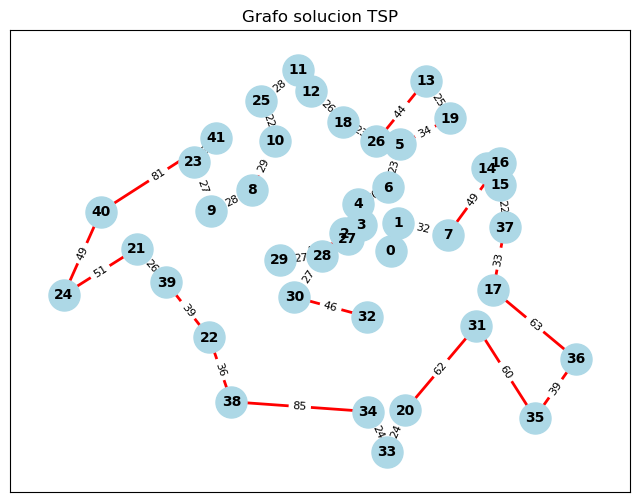

In [19]:
###############################################################################
# Ejecutar el algoritmo
###############################################################################
print("=" * 60)
print("BÚSQUEDA LOCAL CON ENTORNOS VARIABLES (VNS)")
print("=" * 60)

# Ejecutamos el algoritmo utilizando:
# solucion: ruta inicial previamente definida.
# max_entornos = 3: wap, 2-opt y Or-opt.
# max_iter = 50: máximo de ciclos globales del VNS.
mejor_solucion_vns = busqueda_local_entornos_variables(solucion_inicial=solucion, max_entornos=3, max_iter=50)

###############################################################################
# Mostrar solución
###############################################################################
print("\nMejor solución encontrada:")
print(mejor_solucion_vns)

# Graficar solución
plot_tsp_solution(problem.edge_weights, mejor_solucion_vns)

---
## Recocido simulado: Mejora en la selección de vecinos
La mejora del **Recocido simulado** es usar varios tipos de movimientos y elegir entre ellos aleatoriamente. Así el algoritmo explora distintos entornos: intercambio de nodos, inversión de un segmento y extracción/reinserción de un nodo. Esto aumenta la capacidad de escapar de mínimos locales sin cambiar la lógica fundamental del recocido simulado.

### Mejora principal:
- Se incorporan diferentes formas de generar soluciones vecinas.
- Se selecciona aleatoriamente el tipo de movimiento.
- Se mantiene la aceptación probabilística de soluciones peores.
- Se almacena siempre la mejor solución global encontrada.

El objetivo del algoritmo es resolver un problema TSP buscando una ruta de menor distancia. A diferencia de una búsqueda local tradicional, el Recocido Simulado permite aceptar ocasionalmente soluciones peores para intentar escapar de mínimos locales.

**Nota**: Las funciones de probabilidad y bajar_temperatura son las mismas.

In [20]:
###############################################################################
# RECOCIDO SIMULADO MEJORADO
###############################################################################
###############################################################################
# ENTORNO 1: INTERCAMBIO DE DOS NODOS - SWAP
###############################################################################
def genera_vecina_swap(solucion):
    """
    Genera una solución vecina intercambiando dos nodos aleatorios. 
    El nodo ubicado en la posición 0 no se modifica para mantener fija la ciudad inicial del recorrido.
    """
    # Seleccionamos dos posiciones diferentes de la ruta.
    i, j = sorted(random.sample(range(1, len(solucion)), 2))

    # Creamos una copia de la solución original para no modificarla.
    vecina = solucion[:]

    # Intercambiamos los nodos que se encuentran en las posiciones i y j.
    vecina[i], vecina[j] = vecina[j], vecina[i]

    # Devolvemos la nueva solución vecina.
    return vecina

In [21]:
###############################################################################
# ENTORNO 2: INVERSIÓN DE UN SEGMENTO - 2-OPT
###############################################################################
def genera_vecina_2opt(solucion):
    """
    Genera una solución vecina invirtiendo un segmento de la ruta.
    Este movimiento es especialmente útil para el TSP porque permite reorganizar varios nodos simultáneamente y puede eliminar cruces
    innecesarios entre aristas.

    Ejemplo:
        Original:
        [0, 1, 2, 3, 4, 5]

        Si i=2 y j=4:

        Segmento:
        [2, 3, 4]

        Segmento invertido:
        [4, 3, 2]

        Resultado:
        [0, 1, 4, 3, 2, 5]
    """

    # Seleccionamos dos posiciones diferentes de forma aleatoria. No se utiliza la posición 0 para conservar el nodo inicial.
    i, j = sorted(random.sample(range(1, len(solucion)), 2))

    # Creamos una copia independiente de la solución.
    vecina = solucion[:]

    # Seleccionamos el segmento comprendido entre i y j y lo invertimos.
    # j + 1 permite incluir también el nodo ubicado en j.
    vecina[i:j + 1] = reversed(
        vecina[i:j + 1]
    )

    # Devolvemos la solución modificada.
    return vecina

In [22]:
###############################################################################
# ENTORNO 3: REUBICACIÓN DE UN NODO - RELOCATE
###############################################################################
def genera_vecina_relocate(solucion):
    """
    Genera una solución vecina extrayendo un nodo de la ruta e insertándolo posteriormente en otra posición.
    Ejemplo:
        Original:
        [0, 1, 2, 3, 4, 5]

        Extraemos el nodo 2:
        [0, 1, 3, 4, 5]

        Lo insertamos en otra posición:
        [0, 1, 3, 4, 2, 5]

    Este movimiento permite explorar modificaciones diferentes a las producidas mediante Swap y 2-opt.
    """

    # Creamos una copia de la solución original.
    vecina = solucion[:]

    # Seleccionamos aleatoriamente la posición del nodo que será movido.
    # Se empieza desde 1 para conservar el nodo inicial.
    i = random.randrange(1, len(vecina))

    # Extraemos el nodo seleccionado. pop(i) elimina el elemento de la posición i y devuelve el nodo eliminado.
    nodo = vecina.pop(i)

    # Seleccionamos aleatoriamente una nueva posición para colocar el nodo.
    j = random.randrange(1, len(vecina) + 1)

    # Insertamos el nodo en su nueva posición.
    vecina.insert(j, nodo)

    # Devolvemos la solución vecina generada.
    return vecina

In [23]:
###############################################################################
# GENERADOR DE SOLUCIONES VECINAS
###############################################################################
def genera_vecina_aleatorio(solucion):
    """
    Genera una solución vecina seleccionando aleatoriamente no de los tres tipos de movimientos disponibles:
        1. Swap
        2. 2-opt
        3. Relocate

    Esta es la principal mejora respecto al algoritmo original, donde solamente se utilizaba el intercambio aleatorio de dos nodos.
    Al disponer de diferentes estructuras de vecindad, se incrementa la diversidad de soluciones que puede
    explorar el Recocido Simulado.
    """

    # Creamos una lista que contiene las tres funciones disponibles para generar soluciones vecinas.
    entornos = [genera_vecina_swap, genera_vecina_2opt, genera_vecina_relocate]

    # random.choice selecciona aleatoriamente una de las funciones anteriores.
    generador = random.choice(entornos)

    # Devuelve directamente la nueva solución vecina.
    return generador(solucion)

In [24]:
###############################################################################
# ALGORITMO PRINCIPAL DE RECOCIDO SIMULADO
###############################################################################
def recocido_simulado(problem, TEMPERATURA, temperatura_minima=0.0001):
    ###########################################################################
    # 1. GENERAR SOLUCIÓN INICIAL
    ###########################################################################
    # Creamos una solución inicial aleatoria. Esta será el punto desde el cual comienza la exploración del espacio de soluciones.
    solucion_referencia = crear_solucion(Nodos)

    # Calculamos la distancia total de la solución inicial: Esta distancia será utilizada como referencia para comparar las nuevas soluciones vecinas.
    distancia_referencia = distancia_total(solucion_referencia, problem)

    ###########################################################################
    # 2. INICIALIZAR LA MEJOR SOLUCIÓN GLOBAL
    ###########################################################################
    # Inicialmente la mejor solución encontrada es la misma solución de referencia.
    mejor_solucion = solucion_referencia[:]

    # Guardamos la distancia correspondiente a la mejor solución conocida hasta el momento.
    mejor_distancia = distancia_referencia

    ###########################################################################
    # 3. INICIALIZAR CONTADOR DE ITERACIONES
    ###########################################################################
    # Permitirá conocer cuántas iteraciones ejecutó el algoritmo antes de alcanzar la temperatura mínima.
    N = 0

    ###########################################################################
    # 4. BUCLE PRINCIPAL DEL RECOCIDO SIMULADO
    ###########################################################################
    # El algoritmo continúa mientras la temperatura actual sea mayor que la temperatura mínima definida.
    while TEMPERATURA > temperatura_minima:
        N += 1
        #######################################################################
        # Generar una solución vecina
        #######################################################################
        # A partir de la solución de referencia se genera una nueva solución vecina.
        vecina = genera_vecina_aleatorio(solucion_referencia)

        #######################################################################
        # Calcular la distancia de la solución vecina
        #######################################################################
        # Evaluamos la calidad de la nueva solución calculando su distancia total.
        distancia_vecina = distancia_total(vecina,problem)

        #######################################################################
        # Calcular la diferencia entre las dos soluciones
        #######################################################################
        # Calculamos cuánto mejora o empeora la nueva solución.
        # delta < 0: la vecina es mejor.
        # delta = 0: tienen la misma distancia.
        # delta > 0: la vecina es peor.
        delta = (distancia_vecina - distancia_referencia)

        #######################################################################
        # Decidir si se acepta la solución vecina
        #######################################################################
        # CASO 1: Si delta < 0 significa que: distancia_vecina < distancia_referencia
        # Por lo tanto, la nueva solución es mejor y se acepta directamente.
        if delta < 0:
            solucion_referencia = vecina
            distancia_referencia = distancia_vecina

        # CASO 2: Si la solución no es mejor, todavía puede aceptarse de acuerdo con la función probabilística.
        # Esta aceptación de soluciones peores es la que permite que el Recocido Simulado pueda escapar de mínimos locales.
        elif probabilidad(TEMPERATURA, delta):
            # La solución peor pasa temporalmente a ser la nueva solución de referencia.
            solucion_referencia = vecina
            # Su distancia también pasa a ser la nueva distancia de referencia.
            distancia_referencia = distancia_vecina

        #######################################################################
        # Actualizar la mejor solución global
        #######################################################################
        # El algoritmo puede aceptar temporalmente soluciones peores, pero nunca pierde la mejor solución encontrada.
        # Si la solución actual tiene una distancia menor que la mejor distancia conocida, se actualiza.
        if distancia_referencia < mejor_distancia:
            # Guardamos una copia de la mejor ruta encontrada.
            mejor_solucion = solucion_referencia[:]
            # Guardamos su distancia.
            mejor_distancia = distancia_referencia

        
        # Reducir la temperatura
        TEMPERATURA = bajar_temperatura(TEMPERATURA)

    ###########################################################################
    # Mostrar los resultados
    ###########################################################################

    # Mostramos el número total de iteraciones ejecutadas.
    print("Número de iteraciones:", N)

    # Mostramos la mejor ruta encontrada durante toda la ejecución del algoritmo.
    print("La mejor solución encontrada es:", mejor_solucion)

    # Mostramos la distancia total
    # correspondiente a la mejor ruta.
    print("Con una distancia total de:", mejor_distancia)

    # Retornamos la mejor ruta encontrada
    return mejor_solucion

Número de iteraciones: 2521
La mejor solución encontrada es: [0, 28, 30, 8, 23, 41, 40, 24, 21, 39, 9, 29, 22, 38, 33, 20, 34, 32, 2, 3, 1, 27, 4, 12, 10, 25, 11, 18, 26, 5, 14, 7, 31, 36, 35, 17, 37, 15, 16, 19, 13, 6]
Con una distancia total de: 1687


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


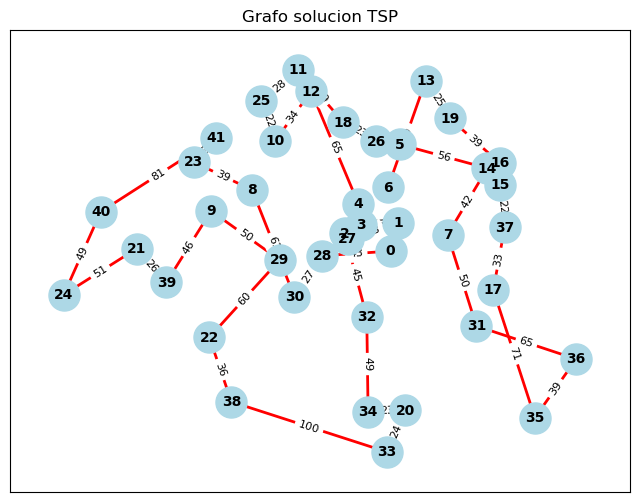

In [25]:
###############################################################################
# Ejecutar el algoritmo
###############################################################################
# Ejecutamos el Recocido Simulado utilizando una temperatura inicial elevada.
sol = recocido_simulado(problem, 10000000)

# Graficamos la mejor ruta obtenida por el algoritmo.
plot_tsp_solution(problem.edge_weights, sol)

### Conclusiones

El desarrollo de esta actividad permitió comprender la importancia de **mejorar la búsqueda global** dentro del espacio de soluciones, ampliando la exploración y reduciendo la posibilidad de que el proceso de optimización quede limitado prematuramente a un mínimo local. En particular, la **mejora en la selección de vecinos**, mediante diferentes movimientos como **Swap, 2-opt y Or-opt**, permitió diversificar la generación de soluciones vecinas y explorar el espacio de búsqueda desde distintas estructuras de vecindad.

En este contexto, el **Recocido Simulado** permitió complementar esta estrategia mediante la aceptación probabilística de soluciones temporalmente peores. Este mecanismo, junto con el descenso progresivo de la temperatura y una selección de vecinos más diversa, favorece un equilibrio entre exploración global y explotación local, incrementando las posibilidades de encontrar rutas de menor distancia y obtener una solución global de mejor calidad.

## Declaración uso IA
Declaro que utilicé herramientas de inteligencia artificial generativa, específicamente **Gemini** y **ChatGPT**, como apoyo en distintas etapas del desarrollo de este trabajo. Su uso estuvo orientado a complementar el proceso de aprendizaje, apoyar la búsqueda inicial de información académica, organizar y sintetizar ideas, y mejorar aspectos de redacción y presentación del trabajo.

Estas herramientas fueron empleadas como base de apoyo al aprendizaje y comprensión académica de la **mejora de la búsqueda global**, permitiendo profundizar en estrategias orientadas a ampliar la exploración del espacio de soluciones y reducir la posibilidad de quedar limitado prematuramente a mínimos locales. En particular, contribuyeron a profundizar en el análisis de la **búsqueda por entornos variables (VNS)** y de diferentes estructuras de vecindad, mediante movimientos como **Swap, 2-opt y Or-opt**, así como en la evaluación de su aporte a la diversificación de las soluciones exploradas.

De igual manera, estas herramientas sirvieron como apoyo para profundizar en el funcionamiento del **Recocido Simulado** como estrategia de optimización, especialmente en el análisis de la **aceptación probabilística de soluciones temporalmente peores**, el descenso progresivo de la temperatura y su capacidad para favorecer la salida de mínimos locales. Esto permitió reforzar el análisis del equilibrio entre **exploración global y explotación local**, así como comprender la importancia de combinar mecanismos de diversificación y selección de vecinos para incrementar la posibilidad de encontrar soluciones de mejor calidad.


Finalmente, las explicaciones y sugerencias obtenidas mediante estas herramientas fueron **revisadas, contrastadas y adaptadas** antes de su incorporación. El planteamiento del problema, el desarrollo de los algoritmos, la ejecución de las pruebas, el análisis de resultados y complejidad, así como las conclusiones, fueron realizados y validados por el autor del presente trabajo.